## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("datasets/Historical_Sales.csv")

In [3]:
df.head()

,Date,SKU,Sessions - Total,Page Views - Total,Units Ordered,Ordered Product Sales,Total Order Items
0,2025-09-01,MN-01,22.0,32.0,6.0,228.10,5.0
1,2025-09-01,MN-02,28.0,33.0,5.0,158.96,5.0
2,2025-09-01,MN-03,9.0,12.0,2.0,81.35,2.0
3,2025-09-01,MN-07,31.0,41.0,2.0,70.11,2.0
4,2025-09-01,MN-09,24.0,32.0,2.0,32.26,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4243 entries, 0 to 4242
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4243 non-null   object 
 1   SKU                    4243 non-null   object 
 2   Sessions - Total       4239 non-null   float64
 3   Page Views - Total     4239 non-null   float64
 4   Units Ordered          4239 non-null   float64
 5   Ordered Product Sales  4239 non-null   float64
 6   Total Order Items      4239 non-null   float64
dtypes: float64(5), object(2)
memory usage: 232.2+ KB


In [5]:
df.shape

(4243, 7)

In [6]:
df.columns 

Index(['Date', 'SKU', 'Sessions - Total', 'Page Views - Total',
       'Units Ordered', 'Ordered Product Sales', 'Total Order Items'],
      dtype='object')

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')

In [8]:
df['Date'].head()
df['Date'].isna().sum()


17

In [9]:
df.isnull().sum()

Date                     17
SKU                       0
Sessions - Total          4
Page Views - Total        4
Units Ordered             4
Ordered Product Sales     4
Total Order Items         4
dtype: int64

In [10]:
numeric_cols = [
    'Sessions - Total',
    'Page Views - Total',
    'Units Ordered',
    'Ordered Product Sales',
    'Total Order Items'
]

df[numeric_cols] = df[numeric_cols].fillna(0)

In [11]:
df = df.dropna(subset=['Date'])

In [12]:
df.isna().sum()

Date                     0
SKU                      0
Sessions - Total         0
Page Views - Total       0
Units Ordered            0
Ordered Product Sales    0
Total Order Items        0
dtype: int64

In [13]:
df = df.sort_values(by='Date')

In [14]:
zero_sales_days = df[df['Units Ordered'] == 0]

In [15]:
high_sales_days = df[df['Ordered Product Sales'] > df['Ordered Product Sales'].quantile(0.90)]

In [16]:
high_sales_days

,Date,SKU,Sessions - Total,Page Views - Total,Units Ordered,Ordered Product Sales,Total Order Items
34,2025-09-01,MN-41,23.0,29.0,23.0,1815.80,11.0
35,2025-09-01,MN-42,15.0,23.0,17.0,1209.13,6.0
19,2025-09-01,MN-25,66.0,94.0,31.0,1126.10,24.0
78,2025-09-02,MN-41,35.0,47.0,44.0,3472.35,24.0
63,2025-09-02,MN-26,29.0,41.0,25.0,780.99,10.0
...,...,...,...,...,...,...,...
4129,2025-11-28,MN-25,66.0,87.0,36.0,1298.19,19.0
4176,2025-11-29,MN-25,56.0,77.0,29.0,1042.69,18.0
4227,2025-11-30,MN-36,88.0,123.0,23.0,777.48,23.0
4234,2025-11-30,MN-42,15.0,19.0,11.0,775.83,7.0


In [17]:
sku_summary = df.groupby('SKU').agg({
    'Sessions - Total': 'sum',
    'Units Ordered': 'sum',
    'Ordered Product Sales': 'sum',
    'Total Order Items': 'sum'
}).reset_index()

In [18]:
sku_summary.sort_values(by='Ordered Product Sales', ascending=False)

,SKU,Sessions - Total,Units Ordered,Ordered Product Sales,Total Order Items
24,MN-25,9214.0,4471.0,162093.76,3059.0
40,MN-41,2046.0,1613.0,124522.16,823.0
41,MN-42,1967.0,1267.0,90693.93,626.0
35,MN-36,8393.0,2255.0,76049.52,2122.0
18,MN-19,9424.0,1645.0,69270.69,1546.0
27,MN-28,4178.0,2480.0,67191.91,1727.0
14,MN-15,10231.0,2335.0,57290.30,2135.0
25,MN-26,2182.0,1663.0,51943.06,841.0
37,MN-38,4840.0,1578.0,51402.66,777.0
13,MN-14,4293.0,1381.0,41153.60,1043.0


In [19]:
daily_summary = df.groupby('Date').agg({
    'Sessions - Total': 'sum',
    'Page Views - Total': 'sum',
    'Units Ordered': 'sum',
    'Ordered Product Sales': 'sum'
}).reset_index()

In [20]:
daily_summary.head()

,Date,Sessions - Total,Page Views - Total,Units Ordered,Ordered Product Sales
0,2025-09-01,1047.0,1437.0,335.0,11554.87
1,2025-09-02,1172.0,1597.0,411.0,14877.42
2,2025-09-03,1265.0,1775.0,444.0,15436.08
3,2025-09-04,1220.0,1646.0,426.0,15405.19
4,2025-09-05,1105.0,1464.0,381.0,14120.94


In [21]:
sales_outliers = df[df['Ordered Product Sales'] > df['Ordered Product Sales'].quantile(0.95)]

In [22]:
sales_outliers

,Date,SKU,Sessions - Total,Page Views - Total,Units Ordered,Ordered Product Sales,Total Order Items
34,2025-09-01,MN-41,23.0,29.0,23.0,1815.80,11.0
35,2025-09-01,MN-42,15.0,23.0,17.0,1209.13,6.0
19,2025-09-01,MN-25,66.0,94.0,31.0,1126.10,24.0
78,2025-09-02,MN-41,35.0,47.0,44.0,3472.35,24.0
107,2025-09-03,MN-26,17.0,22.0,46.0,1431.00,8.0
...,...,...,...,...,...,...,...
4006,2025-11-25,MN-36,144.0,220.0,47.0,1618.36,44.0
3982,2025-11-25,MN-15,185.0,270.0,49.0,1225.53,48.0
4056,2025-11-26,MN-41,21.0,26.0,18.0,1437.10,9.0
4041,2025-11-26,MN-25,107.0,147.0,50.0,1818.61,38.0


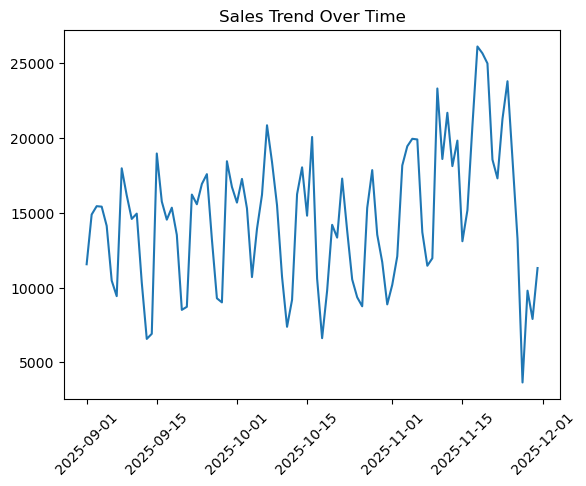

In [23]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(d_toggle := daily_summary['Date'], daily_summary['Ordered Product Sales'])
plt.xticks(rotation=45)
plt.title("Sales Trend Over Time")
plt.show()


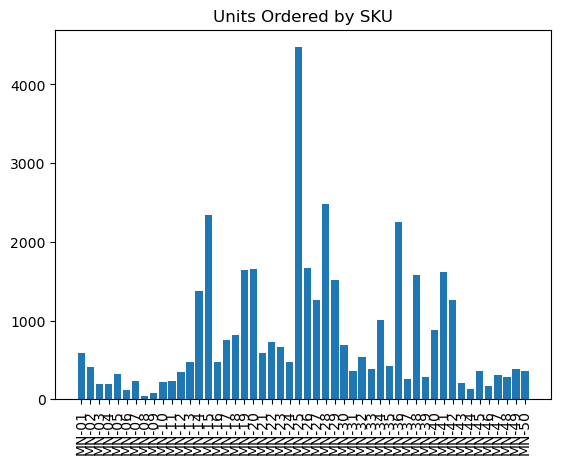

In [24]:
plt.figure()
plt.bar(sku_summary['SKU'], sku_summary['Units Ordered'])
plt.xticks(rotation=90)
plt.title("Units Ordered by SKU")
plt.show()


In [25]:
df.to_csv("cleaned_Historical_Sales.csv", index=False)